# Risk Management per Trade — Kelly, Optimal f y f truncado por Risk of Ruin
*Autor: Juan David Suarez — completado con el ejemplo integral*

Basado en *The Handbook of Portfolio Mathematics* (Ralph Vince) y *Building Algorithmic Trading Systems* (Kevin J. Davey).

Este notebook toma los retornos por trade de una estrategia y construye, paso a paso:

1. **Estadísticas** de la estrategia (win rate, risk/reward, peor pérdida).
2. **Kelly Criteria** — la fracción clásica.
3. **Optimal f de Vince** (Ec. 4.06–4.08) — el f que maximiza la media geométrica.
4. **f truncado por Risk of Drawdown** (Cap. 12) — el mayor f cuya probabilidad de ruina queda bajo tu tolerancia.
5. **Curvas de retorno acumulado** comparando las cuatro reglas de sizing.

Es muy importante aclarar que el siszing que estamos trabajando aca es solo para una estrategia! Pero es un herramiento muy util para explicar la imporntancia del risk management y puede ser usado para traders discrecionales

In [1]:
# Librerias
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Cargar los retornos por trade

In [2]:
rtn_per_trade = pd.read_csv('rtn_strat.csv', index_col=0)['0']
rtn_per_trade.name = 'rtn'
print(f'Numero de trades: {rtn_per_trade.count()}')
rtn_per_trade.head()

Numero de trades: 299


0   -0.030561
1    0.076667
2   -0.000206
3    0.019421
4    0.009243
Name: rtn, dtype: float64

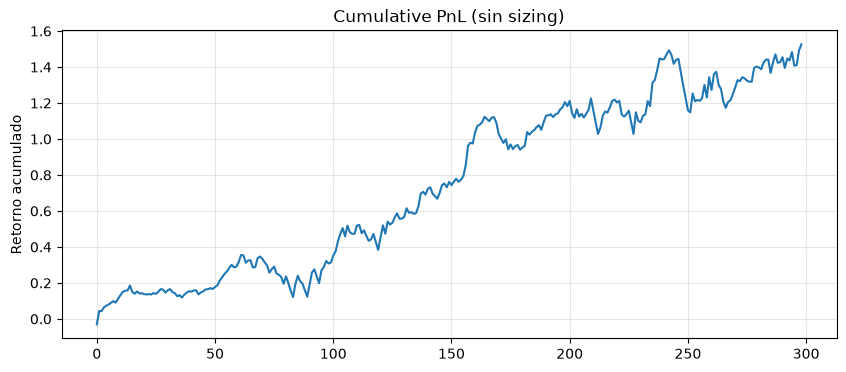

In [3]:
# Curva de equity sin apalancar (la estrategia tal cual, 1 unidad por trade)
((1 + rtn_per_trade).cumprod() - 1).plot(title='Cumulative PnL (sin sizing)', figsize=(10,4))
plt.ylabel('Retorno acumulado'); plt.grid(alpha=.3); plt.show()

## 2. Estadisticas de la estrategia

In [4]:
total_num = rtn_per_trade.count()
win_rate  = rtn_per_trade[rtn_per_trade > 0].count() / total_num
loss_rate = rtn_per_trade[rtn_per_trade < 0].count() / total_num

avg_positive_value = rtn_per_trade[rtn_per_trade > 0].mean()
avg_negative_value = rtn_per_trade[rtn_per_trade < 0].mean()
risk_reward = avg_positive_value / np.abs(avg_negative_value)

biggest_loss = rtn_per_trade.min()   # el peor trade -> clave para optimal f

print(f'Total trades        : {total_num}')
print(f'Win rate            : {win_rate:.3f}')
print(f'Loss rate           : {loss_rate:.3f}')
print(f'Avg win             : {avg_positive_value:.4f}')
print(f'Avg loss            : {avg_negative_value:.4f}')
print(f'Risk/Reward (W/L)   : {risk_reward:.3f}')
print(f'Biggest loss        : {biggest_loss:.4f}')

Total trades        : 299
Win rate            : 0.602
Loss rate           : 0.398
Avg win             : 0.0164
Avg loss            : -0.0165
Risk/Reward (W/L)   : 0.996
Biggest loss        : -0.0353


## 3. Kelly Criteria

$$f_{Kelly} = W - \frac{1-W}{RR} = \text{win rate} - \frac{\text{loss rate}}{\text{risk/reward}}$$

Donde $RR$ = ganancia media / |pérdida media|. Es la fracción óptima cuando modelas la estrategia como una apuesta con dos resultados promedio.
EN este caso kelly significa que en una operacion queremos buscar el tamano que permita perder el 20% de mi capital

In [5]:
f_kelly = win_rate - (loss_rate / risk_reward)

print(f'f_kelly = {f_kelly:.4f}')

f_kelly = 0.2024


Para el ejemplo vamos a asumir que el siguiente trade va a estar basado en la perdida maxima de la estrategia, pero tambien se podria encontrar basado la estrategia de stop loss que se defina. 


In [6]:
# Si nuestro capital hoy es 100.000 el biggest loss es:
aum=100000
money_bl=biggest_loss*aum

# Cual es el position value para una perdida de money_bl: 
position_value=money_bl/f_kelly

# El numero de contratos si el precio es 57.60 seria:
price=57.60
contracts=np.abs(np.round((position_value/price),0))

In [7]:
print(f'Kelly                                          : {f_kelly}')
print(f'AUM                                            : {aum:.3f}')
print(f'Max loss in money                              : {money_bl:.3f}')
print(f'Position value                                 : {position_value:.3f}')
print(f'Trade Number of contract if price is {price}      : {contracts:.3f}')


Kelly                                          : 0.20239526191919932
AUM                                            : 100000.000
Max loss in money                              : -3530.645
Position value                                 : -17444.308
Trade Number of contract if price is 57.6      : 303.000


##### Como se veria el retorno de la estrategia?
dado que definimos la perdida maxima el punto para el sizing voy a asumir que -trade/biggest loss es el porcentaje que perderia por cada trade. 
Asi si perdimos la mitad del biggest_loss eso significa que seria el 50%. 

Nota: Dado que la perdida maxima es un negativo para que se preserven los signos del trade (positivo con positivo) se va a multiplicar tambien por -1


In [8]:
scale_risk=(-rtn_per_trade/biggest_loss)
print(' ############### Escala sin f de kelly ########################')
display(scale_risk.iloc[:5])

print(' ############### Escala com f de kelly ########################')
display((scale_risk*f_kelly).iloc[:5])

 ############### Escala sin f de kelly ########################


0   -0.865605
1    2.171463
2   -0.005821
3    0.550056
4    0.261805
Name: rtn, dtype: float64

 ############### Escala com f de kelly ########################


0   -0.175194
1    0.439494
2   -0.001178
3    0.111329
4    0.052988
Name: rtn, dtype: float64

Veamos como se veria el retorno acumulado

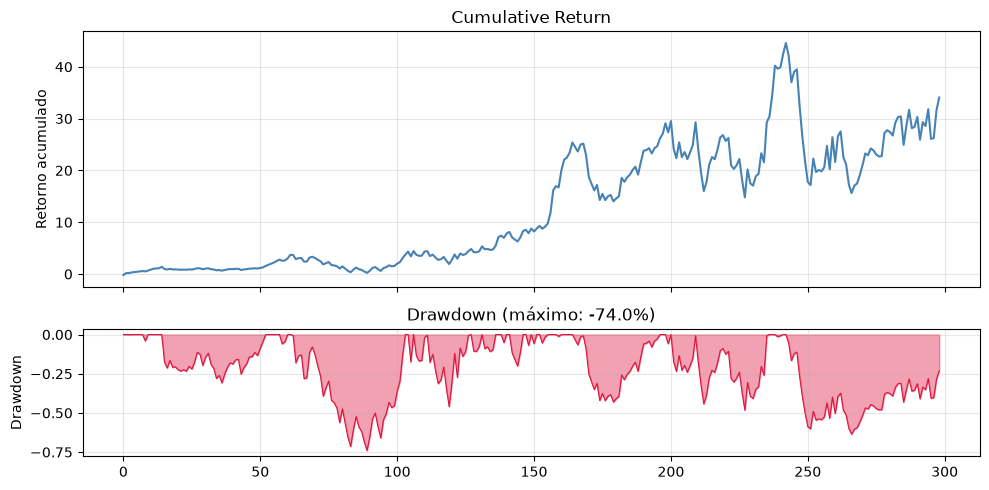

Máximo drawdown: -74.02%


In [9]:
# crear el equity  o el twr
equity_kelly = (1 + scale_risk * f_kelly).cumprod()

# Drawdown: caída desde el máximo acumulado (high-water mark)
running_max = equity_kelly.cummax()
drawdown_kelly = equity_kelly / running_max - 1        # 0 en máximos, negativo en caídas

# Gráfica con dos paneles: equity arriba, drawdown abajo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Panel superior: retorno acumulado (tu curva original)
(equity_kelly - 1).plot(ax=ax1, title='Cumulative Return', color='steelblue')
ax1.set_ylabel('Retorno acumulado')
ax1.grid(alpha=.3)

# Panel inferior: drawdown
ax2.fill_between(drawdown_kelly.index, drawdown_kelly.values, 0, color='crimson', alpha=.4)
ax2.plot(drawdown_kelly.index, drawdown_kelly.values, color='crimson', lw=.8)
ax2.set_ylabel('Drawdown')
ax2.set_title(f'Drawdown (máximo: {drawdown_kelly.min()*100:.1f}%)')
ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

print(f'Máximo drawdown: {drawdown_kelly.min()*100:.2f}%')    


### Que fallas tiene? 
1. Drawdowns muy altos (depende de apetito por el riesgo)
2. Se basa en los trades promedio 

## 4. Optimal f de Vince (Ec. 4.06 – 4.08)

A diferencia de Kelly, el optimal f usa **cada trade individual** (no solo los promedios) y normaliza por la peor pérdida:

$$HPR_i = 1 + f \cdot \frac{-trade_i}{\text{biggest loss}} \qquad (4.06)$$
$$TWR(f) = \prod_{i=1}^{N} HPR_i \qquad (4.07)$$
$$\text{Geo. Mean}(f) = TWR(f)^{1/N} \qquad (4.08)$$

$f^*$ = el valor que **maximiza el TWR** (equivalentemente la media geométrica). Se busca barriendo f de 0.01 a 1.

In [10]:
def twr(f, trades=rtn_per_trade.values, bl=biggest_loss):
    """TWR(f) = producto de los HPR. Devuelve 0 si algun HPR<=0 (quiebra)."""
    hpr = 1 + f * (-trades / bl)
    return hpr.prod()

def geo_mean(f, n=total_num):
    t = twr(f)
    return t ** (1/n) if t > 0 else 0.0

# Una forma de optimizar es con un grid search en el que se exploren diferentes tipos de sizes. En este caso vamos a ir de 0.01 a 1
fs = np.arange(0.01, 1.0, 0.01)
twrs = [twr(f) for f in fs]

# De todos las posibilidades encontramos el pico 
optim_index=int(np.argmax(twrs))
f_coarse = fs[optim_index]

# Cerca al pico exploramos con mayor granularidad. Lo limitamos a 1 y 0.01
fine = np.arange(max(1e-4, f_coarse-0.01), min(1.0, f_coarse+0.01), 0.0001)
f_optimal = fine[int(np.argmax([twr(f) for f in fine]))]


print(f'Optimal f* = {f_optimal:.4f}')
print(f'TWR(f*)    = {twr(f_optimal):.3f}')
print(f'Geo.Mean   = {geo_mean(f_optimal):.5f}  ({(geo_mean(f_optimal)-1)*100:+.3f}% por trade)')
print(f'\nComparacion: f_kelly={f_kelly:.4f}  vs  f_optimal={f_optimal:.4f}')


Optimal f* = 0.2738
TWR(f*)    = 45.540
Geo.Mean   = 1.01285  (+1.285% por trade)

Comparacion: f_kelly=0.2024  vs  f_optimal=0.2738


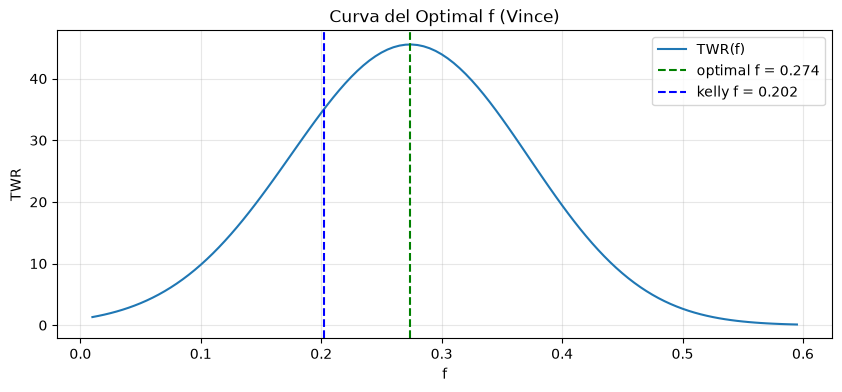

In [11]:
# Visualizar la curva TWR(f): el pico y el 'acantilado'
fs_plot = np.arange(0.01, 0.6, 0.005)
plt.figure(figsize=(10,4))
plt.plot(fs_plot, [twr(f) for f in fs_plot], label='TWR(f)')
plt.axvline(f_optimal, color='g', ls='--', label=f'optimal f = {f_optimal:.3f}')
plt.axvline(f_kelly, color='b', ls='--', label=f'kelly f = {f_kelly:.3f}')
plt.xlabel('f'); plt.ylabel('TWR'); plt.title('Curva del Optimal f (Vince)')
plt.legend(); plt.grid(alpha=.3); plt.show()

#### Comparacion Kelly f optimo

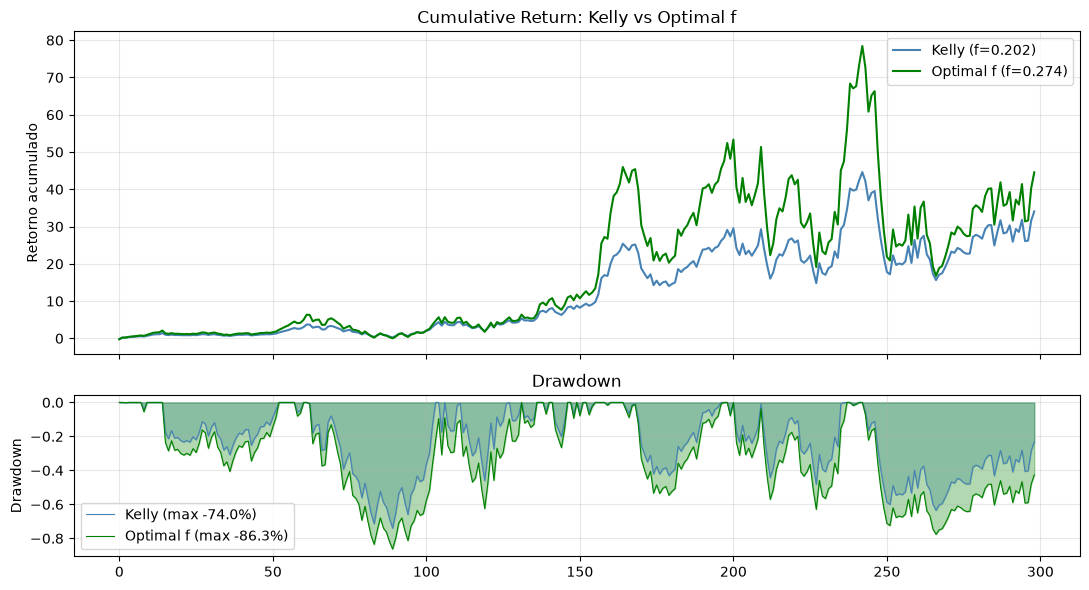

Máximo drawdown Kelly    : -74.02%
Máximo drawdown Optimal f: -86.29%


In [12]:
# Equity de cada regla (empieza en 1)
equity_kelly     = (1 + scale_risk * f_kelly).cumprod()
equity_f_optimal = (1 + scale_risk * f_optimal).cumprod()

# Drawdown: caída desde el máximo acumulado (high-water mark)
drawdown_kelly = equity_kelly / equity_kelly.cummax() - 1
drawdown_f     = equity_f_optimal / equity_f_optimal.cummax() - 1

# Gráfica con dos paneles: equity arriba, drawdown abajo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# Panel superior: retorno acumulado de ambas
(equity_kelly - 1).plot(ax=ax1, color='steelblue',
                        label=f'Kelly (f={f_kelly:.3f})')
(equity_f_optimal - 1).plot(ax=ax1, color='green',
                            label=f'Optimal f (f={f_optimal:.3f})')
ax1.set_title('Cumulative Return: Kelly vs Optimal f')
ax1.set_ylabel('Retorno acumulado')
ax1.legend()
ax1.grid(alpha=.3)

# Panel inferior: drawdown de ambas
ax2.fill_between(drawdown_kelly.index, drawdown_kelly.values, 0,
                 color='steelblue', alpha=.3)
ax2.plot(drawdown_kelly.index, drawdown_kelly.values, color='steelblue', lw=.8,
         label=f'Kelly (max {drawdown_kelly.min()*100:.1f}%)')
ax2.fill_between(drawdown_f.index, drawdown_f.values, 0,
                 color='green', alpha=.3)
ax2.plot(drawdown_f.index, drawdown_f.values, color='green', lw=.8,
         label=f'Optimal f (max {drawdown_f.min()*100:.1f}%)')
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdown')
ax2.legend()
ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

print(f'Máximo drawdown Kelly    : {drawdown_kelly.min()*100:.2f}%')
print(f'Máximo drawdown Optimal f: {drawdown_f.min()*100:.2f}%')


## 5. f truncado por Risk of Drawdown (Cap. 12)

El optimal f es **agresivo** por lo que pudimos ver arriba. Con un drawdwon del 80% necesitariamos triplicar el capital. 

Para esto, Ralph vince en Cap. 12 propone con escoger un  **f optimo cuya probabilidad de drawdown quede bajo una tolerancia** que se pueda escoger (ver tambien Kevin J. Davey). Una forma de atacar el problema es poder encontrar la probabilidad de quiebra usando o arboles binomiales o montercalo. En este caso voy a hacer el ejemplo con montercarlo aplicando la solucion vectorial de ralph vince que se explica a continuacion

**Supuestos**

Numero de trades: q

limite_drawdown: b

### Forma vectorial de construir el indicador β de Vince (ojo no es lo mismo que la b de apartado anterior) 

En vez de recorrer el camino comprobando en cada trade `si equity - b <= 0`, 
Se puede vectorizar el calculo

**Paso 1 — Calcular el TWR por cada trade** Para cada trade $t$ del camino se 
calcula el equity acumulado hasta ese punto menos la barrera $b$:

$$x_t = \left(\prod_{s=0}^{t} HPR_s\right) - b$$

- $x_t > 0$  → la cuenta está por encima de la barrera (vivo en ese paso).
- $x_t \le 0$ → la cuenta tocó o cruzó la barrera (ruina en ese paso).

**Paso 2 — El indicador β.** Se define como la suma con signo dividida 
por la suma en valor absoluto:

$$\beta = \frac{\displaystyle\sum_{t=1}^{q} x_t}{\displaystyle\sum_{t=1}^{q} \left| x_t \right|}$$

**Paso 3 — Convertir a binario (Ec. 12.03):**

$$\text{int}\,|\beta| = \begin{cases} 1 & \text{sobrevivió (ningún } x_t < 0) \\ 0 & \text{se arruinó (algún } x_t < 0) \end{cases}$$

### Como se entiende eso

- Si **todos** los $x_t \ge 0$: cada término del numerador es igual a su 
  valor absoluto, entonces numerador = denominador y $\beta = 1$.
- Si **algún** $x_t < 0$: ese término resta en el numerador pero suma en el 
  denominador, entonces numerador < denominador y $\beta < 1$ 
  (posiblemente negativo).

Al aproximar al entero mas cercan $\text{int}\,|\beta|$, obtenemos 1 solo si el camino nunca tocó la 
barrera, y 0 si se arruinó en cualquier punto. Si un la barrera se toca una sola vez, entonces significa que hubo quiebra en ese camino

### Ventaja

El test **vectoriza** sobre todos los caminos, en vez de un 
loop de Python por paso. Lo que permite tener una ganacia de velocidad.

**Nota sobre el caso límite:** si algún $x_t$ es exactamente 0 (el equity toca 
la barrera justo), ese término no aporta ni al numerador ni al denominador, y 
podría no detectarse como ruina. El loop con `if R - b <= 0` es más 
fiel a la Ec. 12.02; el $\beta$ es la optimización algebraica de esa misma idea.

#### Primero simulemos todos los caminos posibles de los trades (boostraping)
Este ejercicio lo voy a hacer sin remplazo (esto requiere que el numero de trades sea mayor al plazo que vamos a analizar)

In [13]:
def montecarlo_simulation(trades, q=50, n_simulation=100000):
    rng = random.Random(7)
    paths = np.zeros((n_simulation, q))          # tupla, orden correcto
    for i in range(n_simulation):                # n_simulation, no trials
        paths[i] = rng.choices(trades, k=q)
    return paths

#### Ahora calculemos la probabilidad de quiebra: 

In [14]:
def ruin_prob_vectorized(paths, f, b, bl):
    """
    Probabilidad de ruina sobre TODOS los caminos de golpe, vectorizado.
    paths: matriz (num_caminos x q) de trades.
    """
    hpr = 1 + f * (-paths / bl)                     # (n_caminos x q)
    equity = np.cumprod(hpr, axis=1)                # cumprod por fila
    
    x = equity - b                                  # (n_caminos x q)
    beta = x.sum(axis=1) / np.abs(x).sum(axis=1)    # un beta por camino
    survived = np.abs(beta).astype(int)             # 1 sobrevivió / 0 ruina
    return 1 - survived.mean()                      # fracción arruinada

In [15]:
# 1. Generar los caminos (matriz n_simulation x q de retornos)
q_trades=50 # Vamos a simular 50 trades
n_simu=10000# Vamos a hace 10000 simulaciones
dd_limit = 0.20              # quiero quebrarme si caigo más del 20%
b_rv = 1 - dd_limit             # Como pusimos el dd ahora tenemos que encontrar el valor del portfolio si escogemos un dd del 20% eso significa que nuestro portfolio llego a 80%
tolerance= 0.05 # la tolerance en porcentaje 

montecarlo_paths = montecarlo_simulation(rtn_per_trade.values, q=q_trades, n_simulation=n_simu)
print(montecarlo_paths.shape)

# 2. Calcula B de vince Uq=
ruin_by_f = {}
for f in np.arange(0.01, 1.0, 0.01):
    ruin_by_f[round(f, 2)] = ruin_prob_vectorized(montecarlo_paths, f, b_rv, biggest_loss)

ruin_series = pd.Series(ruin_by_f, name='prob_ruina')
ruin_series.index.name = 'f'


# F seguro basado en nivel de tolerancia

f_truncado = ruin_series[ruin_series <= tolerance].index.max()
print(f'f máximo con ruina <= {tolerance:.0%}: {f_truncado}')


(10000, 50)
f máximo con ruina <= 5%: 0.04


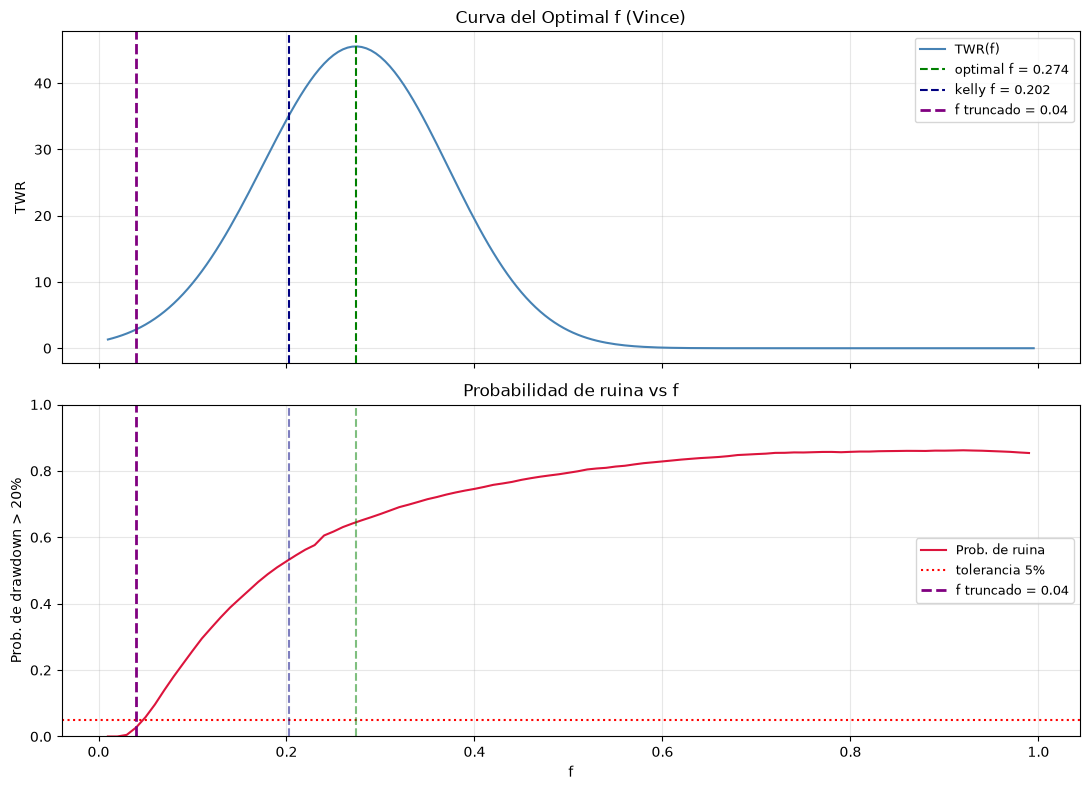

In [16]:
fs_plot = np.arange(0.01, 1, 0.005)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# ===== Panel superior: TWR(f) =====
ax1.plot(fs_plot, [twr(f) for f in fs_plot], color='steelblue', label='TWR(f)')
ax1.axvline(f_optimal, color='g',      ls='--', label=f'optimal f = {f_optimal:.3f}')
ax1.axvline(f_kelly,   color='navy',   ls='--', label=f'kelly f = {f_kelly:.3f}')
ax1.axvline(f_truncado,  color='purple', ls='--', lw=2, label=f'f truncado = {f_truncado}')
ax1.set_ylabel('TWR')
ax1.set_title('Curva del Optimal f (Vince)')
ax1.legend(fontsize=9); ax1.grid(alpha=.3)

# ===== Panel inferior: Probabilidad de ruina =====
ax2.plot(ruin_series.index, ruin_series.values, color='crimson', label='Prob. de ruina')
ax2.axhline(tolerance, color='red', ls=':', label=f'tolerancia {tolerance:.0%}')
ax2.axvline(f_optimal, color='g',      ls='--', alpha=.5)
ax2.axvline(f_kelly,   color='navy',   ls='--', alpha=.5)
ax2.axvline(f_truncado,  color='purple', ls='--', lw=2, label=f'f truncado = {f_truncado}')
ax2.set_xlabel('f')
ax2.set_ylabel('Prob. de drawdown > 20%')
ax2.set_title('Probabilidad de ruina vs f')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

## 6. Apalancamiento

In [17]:
# Mapear cada f de Vince a su apalancamiento equivalente sobre el retorno crudo
lev_kelly     = f_kelly     / abs(biggest_loss)
lev_optimal   = f_optimal   / abs(biggest_loss)
lev_truncated = f_truncado / abs(biggest_loss)
print('Apalancamiento equivalente (f / |biggest_loss|):')
print(f'   kelly     : {lev_kelly:.2f}x')
print(f'   optimal   : {lev_optimal:.2f}x')
print(f'   truncado  : {lev_truncated:.2f}x')

Apalancamiento equivalente (f / |biggest_loss|):
   kelly     : 5.73x
   optimal   : 7.75x
   truncado  : 1.13x


### 6A. Retorno acumulado — interpretacion de Vince (HPR)

Esta es la forma correcta segun el libro: cada trade multiplica la cuenta por `1 + f*(-r/biggest_loss)`. Es la curva que el optimal f realmente maximiza.

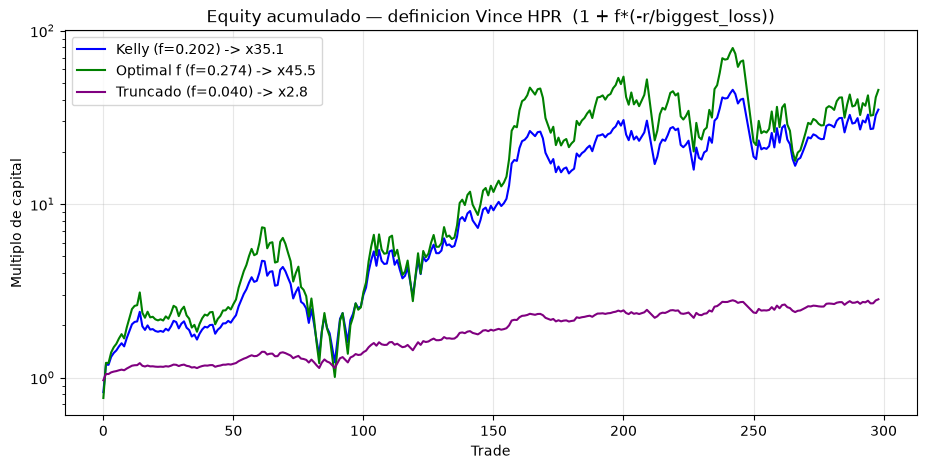

Multiplo final de capital:
   Kelly      (f=0.202): x35.07
   Optimal f  (f=0.274): x45.54
   Truncado   (f=0.040): x2.83


In [18]:
def equity_hpr(f, trades=rtn_per_trade, bl=biggest_loss):
    """Curva de equity bajo la definicion de Vince (HPR)."""
    return (1 + f * (-trades / bl)).cumprod()

plt.figure(figsize=(11,5))
for name, f, c in [('Kelly',     f_kelly,     'b'),
                   ('Optimal f', f_optimal,   'g'),
                   ('Truncado',  f_truncado, 'purple')]:
    eq = equity_hpr(f)
    plt.plot(eq.values, color=c, label=f'{name} (f={f:.3f}) -> x{eq.iloc[-1]:.1f}')
plt.title('Equity acumulado — definicion Vince HPR  (1 + f*(-r/biggest_loss))')
plt.xlabel('Trade'); plt.ylabel('Multiplo de capital'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.show()

print('Multiplo final de capital:')
for name, f in [('Kelly',f_kelly),('Optimal f',f_optimal),('Truncado',f_truncado)]:
    print(f'   {name:10s} (f={f:.3f}): x{equity_hpr(f).iloc[-1]:.2f}')

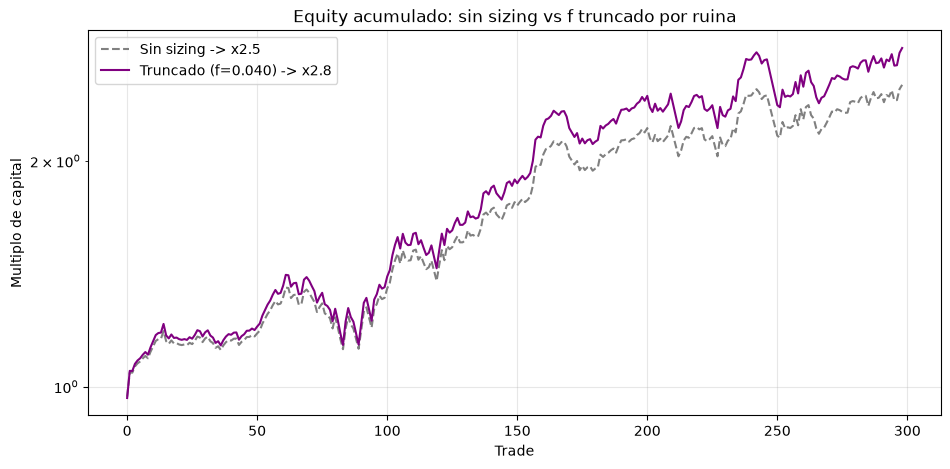

Multiplo final de capital:
   Sin sizing  : x2.53
   Truncado     (f=0.040): x2.83


In [19]:
# Sin sizing = la estrategia tal cual, 1 unidad por trade (retorno crudo)
equity_sin_sizing = (1 + rtn_per_trade).cumprod()

plt.figure(figsize=(11,5))

# Sin sizing (usa su propia definición: retorno crudo, no la HPR de Vince)
plt.plot(equity_sin_sizing.values, color='gray', ls='--',
         label=f'Sin sizing -> x{equity_sin_sizing.iloc[-1]:.1f}')

# f truncado (definición HPR de Vince)
eq_trunc = equity_hpr(f_truncado)
plt.plot(eq_trunc.values, color='purple',
         label=f'Truncado (f={f_truncado:.3f}) -> x{eq_trunc.iloc[-1]:.1f}')

plt.title('Equity acumulado: sin sizing vs f truncado por ruina')
plt.xlabel('Trade'); plt.ylabel('Multiplo de capital'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.show()

print('Multiplo final de capital:')
print(f'   {"Sin sizing":12s}: x{equity_sin_sizing.iloc[-1]:.2f}')
print(f'   {"Truncado":12s} (f={f_truncado:.3f}): x{eq_trunc.iloc[-1]:.2f}')

# 6. Veamos el caso para principiantes? 

In [20]:
### Reglas de riesgo 
# Reglas arriesgar entre el 2% y 3%
risk_per_trade=0.04
# Tipo de trade que se deben buscar: 
risk_reward=3 # Esto significa 1 risk a 3 reward

### Reglas para preservar las ganancias
save_profit=0.5 #50% of profit per trade

### Solo se aumenta el riesgo si se ha hecho dinero
### Usar profit para trades apalancados


# 6.1. Por es importante el risk reward de 3 por uno de riesgo? 
El risk Rewar mayor a tres permite que para ser rentable y tener expectitva matematica deamos tener una probabilidad de exito por operacion de mas del 25%, es decir que de 10 trades necesitamos mas de 2.5!!

In [122]:
p = []
rr = []
for i in range(1, 10):
    print(i)
    p.append(1 / (i + 1))    # P = 1/(rr+1), con rr = i
    rr.append(i)             # el índice ES i, no i+1


1
2
3
4
5
6
7
8
9


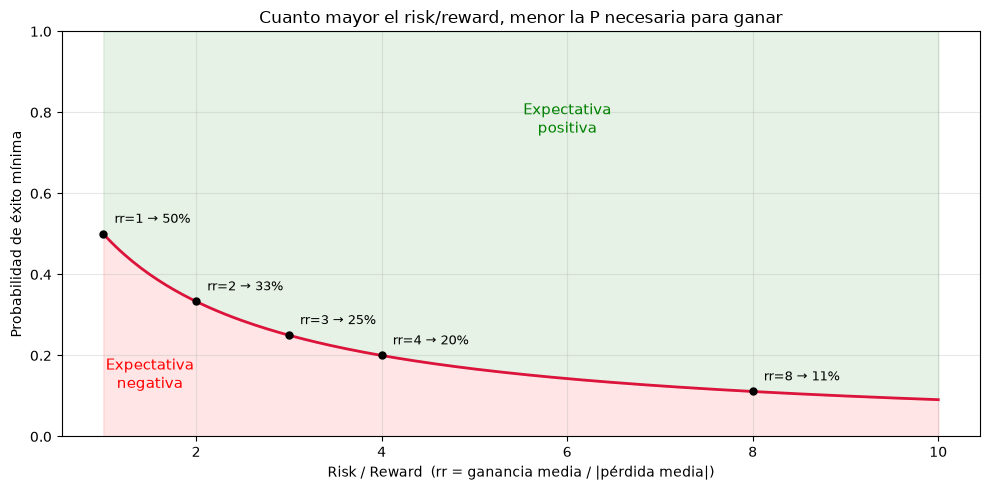

In [123]:
# Curva suave (muchos puntos) en vez de 9 escalones
rr = np.linspace(1, 10, 200)
p_min = 1 / (rr + 1)
rr_df = pd.DataFrame({'P mínima': p_min}, index=rr)

ax = rr_df.plot(figsize=(10, 5), color='crimson', lw=2, legend=False)

# Zonas de expectativa positiva / negativa
ax.fill_between(rr, p_min, 1, alpha=.10, color='green')
ax.fill_between(rr, 0, p_min, alpha=.10, color='red')
ax.text(6, 0.75, 'Expectativa\npositiva', color='green', fontsize=11, ha='center')
ax.text(1.5, 0.12, 'Expectativa\nnegativa', color='red', fontsize=11, ha='center')

# Marcar algunos puntos clave para leer valores concretos
for r in [1, 2, 3, 4,8]:
    pm = 1 / (r + 1)
    ax.plot(r, pm, 'ko', ms=5)
    ax.annotate(f'rr={r} → {pm*100:.0f}%', (r, pm),
                textcoords='offset points', xytext=(8, 8), fontsize=9)

ax.set_xlabel('Risk / Reward  (rr = ganancia media / |pérdida media|)')
ax.set_ylabel('Probabilidad de éxito mínima')
ax.set_title('Cuanto mayor el risk/reward, menor la P necesaria para ganar')
ax.set_ylim(0, 1)
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

# 6.2 Hagamos un ejemplo con una serie de trades de un portafolio de mentiras

### Serie de mentiras

In [23]:

# Solo voy a crear una muestra de trade que me den una relacion de 3 a 1
# Y un profit rate del 30%
muestra_loss = rtn_per_trade[rtn_per_trade < 0].sample(70, random_state=42)
muestra_profit = rtn_per_trade[rtn_per_trade >=0].sample(30, random_state=42)

print('Risk Reward: ' ,muestra_profit.mean()/muestra_loss.mean())
# Los profits los voy a mulstiplicar por 3.5 para que me de una relacion 3 a 1
muestra_profit=muestra_profit*3.5


print('Final Risk Reward: ' ,muestra_profit.mean()/muestra_loss.mean())
serie_combinada =pd.concat([muestra_loss, muestra_profit]).sample(frac=1, random_state=100).reset_index().drop(columns='index')*7


Risk Reward:  -0.9106056272918908
Final Risk Reward:  -3.1871196955216163


# 6.3 Estadisticas de la series de mentiras

<Axes: title={'center': 'Estrategia'}>

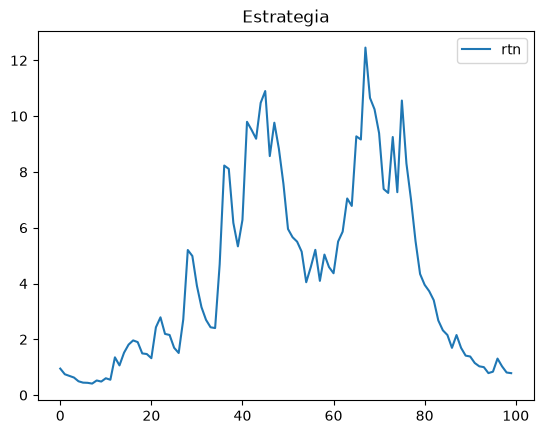

In [24]:
(serie_combinada+1).cumprod().plot(title='Estrategia')


In [25]:
wind_rate=serie_combinada[serie_combinada>0].iloc[:,0].count()/serie_combinada.iloc[:,0].count()
avg_profit=serie_combinada[serie_combinada>=0].iloc[:,0].mean()
avg_loss=serie_combinada[serie_combinada<0].iloc[:,0].mean()
win_rate=avg_profit/-avg_loss
std_loss=serie_combinada[serie_combinada<0].iloc[:,0].std()

print(f'Win rate : {wind_rate}')
print(f'Avg profit rtn : {avg_profit:.3f}')
print(f'Avg loss rtn : {avg_loss:.3f}')
print(f'win_rate : {avg_loss:.3f}')

Win rate : 0.3
Avg profit rtn : 0.384
Avg loss rtn : -0.120
win_rate : -0.120


# 6.4. Backtest de la serie de mentiras

In [26]:
rng = np.random.default_rng(seed=42)   # el 42 es cualquier número que elijas

save_profit = 0.5
init_aum = 100_000

# Aplanar para que cada t sea un número, no un array [número]
rnt_flat = np.asarray(serie_combinada).ravel()

risk_capital = [init_aum]
full_risk_capital=[init_aum]
all_invested=[init_aum]
profit_retained = [0.0]
retained_cum = 0.0

for idx, t in enumerate(rnt_flat[:]):
    t = float(t)                         # garantiza escalar puro
    aum = risk_capital[idx]
    aum_full=full_risk_capital[idx]
    aum_all_inv=all_invested[idx]
    # Vamos a simular la distancion del stop loss
    stop=np.minimum(t,avg_loss)

    # Cuanto vamos a arriesgar en el trade
    risk_amount =  risk_per_trade* aum
    risk_amount_full = risk_per_trade * aum_full
    
    position_size=np.abs(risk_amount/stop)
    position_size_full=np.abs(risk_amount_full/stop)

    #print('Aum:         ',aum)
    #print('Risk Amount: ',risk_amount)
    #print('Stop Loss:   ',avg_loss)
    #print('Position Size ',position_size)
    #print('Final Pnl ',t)

    pnl = position_size* t
    pnl_full_capital = position_size_full*t
    pnl_full_inv = aum_all_inv*t
     
    
    if t >= 0:
        # Vamos a asumir que si perdemos un trade
        # El stop loss va a estar ubicado a 3%
        #print('profit',t* position_size/aum)
        saved   = pnl* save_profit
        to_risk = pnl - saved
        
    else:
        #print('loss',t* position_size/aum)
        saved   = 0.0
        to_risk = pnl
        
    risk_capital.append(aum + to_risk)
    full_risk_capital.append(aum_full + pnl_full_capital)
    all_invested.append(aum_all_inv+pnl_full_inv)
    retained_cum += saved
    profit_retained.append(retained_cum)

result = pd.DataFrame({
    'risk_capital': risk_capital[:],
    'profit_retained': profit_retained[:],
    'full_pnl':full_risk_capital[:],
    'no_risk_m':all_invested,
})
result['patrimonio_total'] = result['risk_capital'] + result['profit_retained']

print(result.tail())

     risk_capital  profit_retained       full_pnl      no_risk_m  \
96   82097.047643    207421.907285  395163.961299   84003.985872   
97   89722.895848    215047.755490  468576.111230  130968.757745   
98   86133.980015    215047.755490  449833.066780  103014.028855   
99   82688.620814    215047.755490  431839.744109   81023.414306   
100  81898.939489    215047.755490  427715.648461   78694.795659   

     patrimonio_total  
96      289518.954927  
97      304770.651339  
98      301181.735505  
99      297736.376304  
100     296946.694979  


# 6.5. Verificar resultados

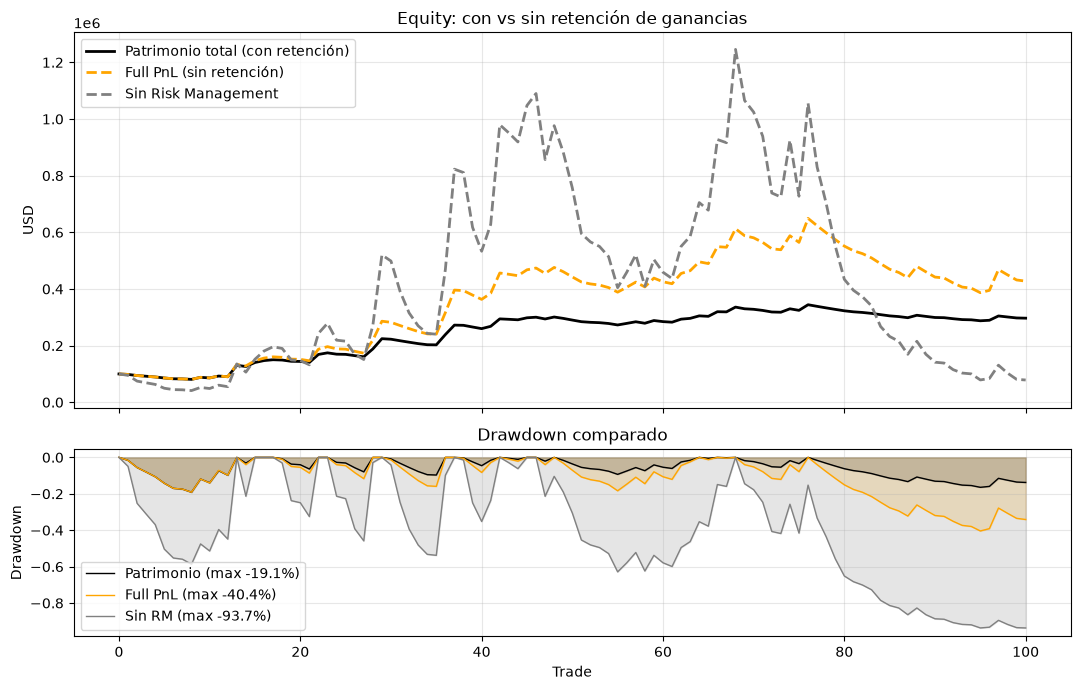

Máximo drawdown patrimonio total : -19.14%
Máximo drawdown full PnL         : -40.41%
Máximo drawdown sin RM           : -93.68%


In [27]:
def drawdown(equity):
    equity = pd.Series(np.asarray(equity).ravel(), index=result.index)
    return equity / equity.cummax() - 1

dd_patrimonio = drawdown(result['patrimonio_total'])
dd_full       = drawdown(result['full_pnl'])
dd_all_inv    = drawdown(result['no_risk_m'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# ===== Panel superior: curvas de equity =====
ax1.plot(result.index, result['patrimonio_total'], color='black', lw=2,
         label='Patrimonio total (con retención)')
ax1.plot(result.index, result['full_pnl'], color='orange', lw=2, ls='--',
         label='Full PnL (sin retención)')
ax1.plot(result.index, result['no_risk_m'], color='grey', lw=2, ls='--',
         label='Sin Risk Management')
ax1.set_ylabel('USD'); ax1.set_title('Equity: con vs sin retención de ganancias')
ax1.legend(); ax1.grid(alpha=.3)

# ===== Panel inferior: drawdowns superpuestos =====
# cada serie: su relleno + su línea, mismo color, etiqueta con SU propio máximo
ax2.fill_between(dd_patrimonio.index, dd_patrimonio.values, 0, color='black', alpha=.20)
ax2.plot(dd_patrimonio.index, dd_patrimonio.values, color='black', lw=1,
         label=f'Patrimonio (max {dd_patrimonio.min()*100:.1f}%)')

ax2.fill_between(dd_full.index, dd_full.values, 0, color='orange', alpha=.20)
ax2.plot(dd_full.index, dd_full.values, color='orange', lw=1,
         label=f'Full PnL (max {dd_full.min()*100:.1f}%)')

ax2.fill_between(dd_all_inv.index, dd_all_inv.values, 0, color='grey', alpha=.20)
ax2.plot(dd_all_inv.index, dd_all_inv.values, color='grey', lw=1,
         label=f'Sin RM (max {dd_all_inv.min()*100:.1f}%)')

ax2.set_ylabel('Drawdown'); ax2.set_xlabel('Trade')
ax2.set_title('Drawdown comparado')
ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

print(f'Máximo drawdown patrimonio total : {dd_patrimonio.min()*100:.2f}%')
print(f'Máximo drawdown full PnL         : {dd_full.min()*100:.2f}%')
print(f'Máximo drawdown sin RM           : {dd_all_inv.min()*100:.2f}%')

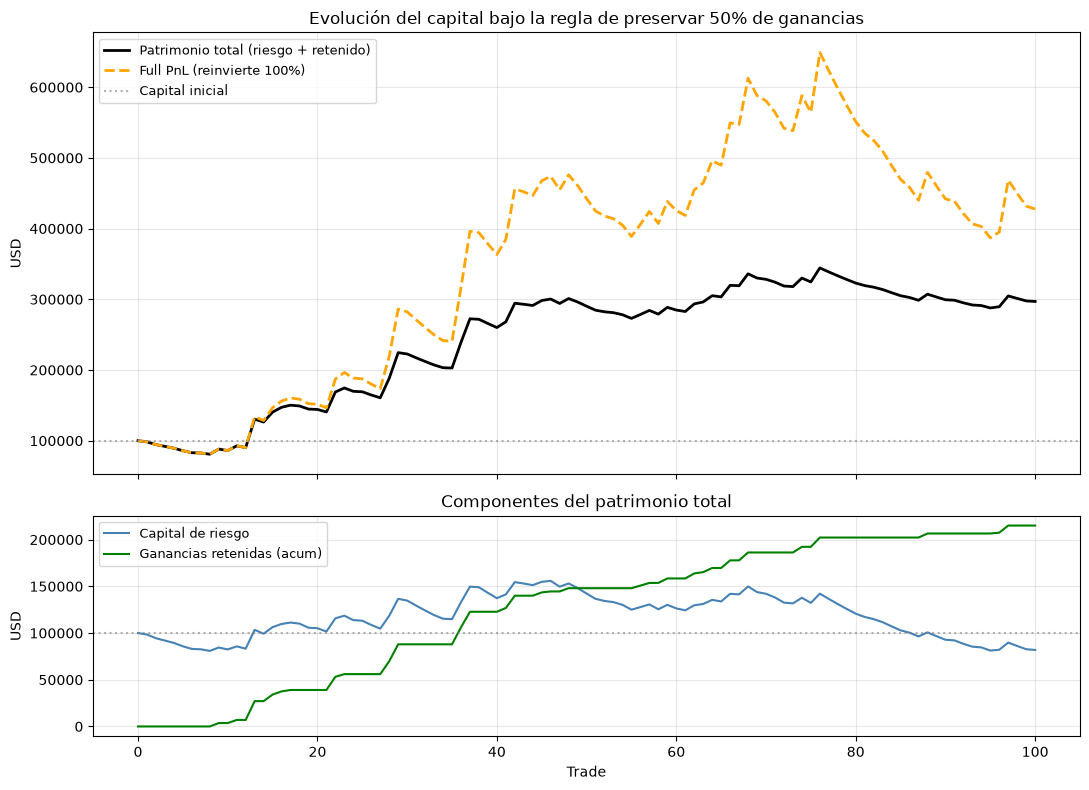

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# ===== Panel superior: patrimonio y comparaciones =====
ax1.plot(result.index, result['patrimonio_total'], color='black', lw=2,
         label='Patrimonio total (riesgo + retenido)')
ax1.plot(result.index, result['full_pnl'], color='orange', lw=2, ls='--',
         label='Full PnL (reinvierte 100%)')

ax1.axhline(init_aum, color='gray', ls=':', alpha=.6, label='Capital inicial')
ax1.set_title('Evolución del capital bajo la regla de preservar 50% de ganancias')
ax1.set_ylabel('USD')
ax1.legend(fontsize=9); ax1.grid(alpha=.3)

# ===== Panel inferior: desglose interno del patrimonio =====
ax2.plot(result.index, result['risk_capital'], color='steelblue',
         label='Capital de riesgo')
ax2.plot(result.index, result['profit_retained'], color='green',
         label='Ganancias retenidas (acum)')
ax2.axhline(init_aum, color='gray', ls=':', alpha=.6)
ax2.set_xlabel('Trade'); ax2.set_ylabel('USD')
ax2.set_title('Componentes del patrimonio total')
ax2.legend(fontsize=9); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

# 6.6. Sera que podemos optimizar el caso principiante? 

In [120]:
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# FUNCIÓN 1: evalúa TWR final y max drawdown POR CAMINO (vectorizada)
# ============================================================
def evaluate_paths(paths, f, save, bl, init=1.0):
    """
    paths: matriz (n_caminos x q) de RETORNOS.
    Devuelve, por camino: twr_final y max_drawdown, con la regla de ahorro.
    - save: fracción de cada ganancia que se aparta (no compone).
    """
    r = paths
    scaled = -r / bl                                # normalizado por biggest loss
    A = np.where(r >= 0, scaled * save, scaled)     # compone (reinvierte 1-save de ganancias)
    B = np.where(r >= 0, scaled * save, 0.0)        # se aparta (ahorro)

    hpr = 1 + f * A
    cum = np.cumprod(hpr, axis=1)
    cum_antes = np.concatenate([np.ones((r.shape[0], 1)), cum[:, :-1]], axis=1)

    risk_path    = init * cum                        # cuenta de riesgo por paso
    savings_path = np.cumsum(init * f * B * cum_antes, axis=1)  # ahorro acumulado
    equity = risk_path + savings_path               # patrimonio total por paso

    twr_final = equity[:, -1] / init
    dd = equity / np.maximum.accumulate(equity, axis=1) - 1
    
    return cum[:,-1], dd.min(axis=1)


# ============================================================
# FUNCIÓN 2: objetivo = TWR mediano SUJETO A restricción de riesgo
# ============================================================
def objective_constrained(paths, f, save, bl, dd_limit=0.30, tol=0.10):
    twr, dd = evaluate_paths(paths, f, save, bl)
    prob_exceed = np.mean(dd < -dd_limit)
    if prob_exceed > tol:
        return np.nan                    # infactible
    return np.median(twr)                # objetivo: TWR del capital de riesgo


def evaluate_grid(paths, bl, f_grid, save_grid):
    TWR = np.zeros((len(f_grid), len(save_grid)))
    DD  = np.zeros((len(f_grid), len(save_grid)))
    for i, f in enumerate(f_grid):
        for j, save in enumerate(save_grid):
            twr, dd = evaluate_paths(paths, f, save, bl)
            TWR[i, j] = np.median(twr)
            DD[i, j]  = np.median(dd)
    return TWR, DD

In [121]:
serie_base=serie_combinada['rtn'].copy()

In [115]:
# Parámetros
DD_LIMIT = 0.30    # drawdown mediano del sistema que toleras
f_grid    = np.arange(0.02, 1.01, 0.03)
save_grid = np.arange(0.0, 0.64, 0.04)


# Biggest loss and montercarlo
biggest_loss_s=serie_base.min()
montecarlo_test=montecarlo_simulation(serie_base.values, q=50, n_simulation=10000)
    

# Calcular ambas superficies
TWR = np.zeros((len(f_grid), len(save_grid)))
DD  = np.zeros((len(f_grid), len(save_grid)))
for i, f in enumerate(f_grid):
    for j, save in enumerate(save_grid):
        twr, dd = evaluate_paths(montecarlo_test, f, save, biggest_loss_s)
        TWR[i, j] = np.mean(twr)
        DD[i, j]  = np.mean(dd)

# Óptimo: max TWR del capital de riesgo, sujeto a DD del sistema aceptable
feasible = DD >= -DD_LIMIT
TWR_feas = np.where(feasible, TWR, np.nan)
i, j = np.unravel_index(np.nanargmax(TWR_feas), TWR.shape)
print(f"Óptimo: f={f_grid[i]:.2f}, save={save_grid[j]:.2f}")
print(f"   TWR capital riesgo : {TWR[i,j]:.2f}x")
print(f"   DD sistema mediano : {DD[i,j]*100:.1f}%")

Óptimo: f=0.02, save=0.60
   TWR capital riesgo : 0.94x
   DD sistema mediano : -9.9%


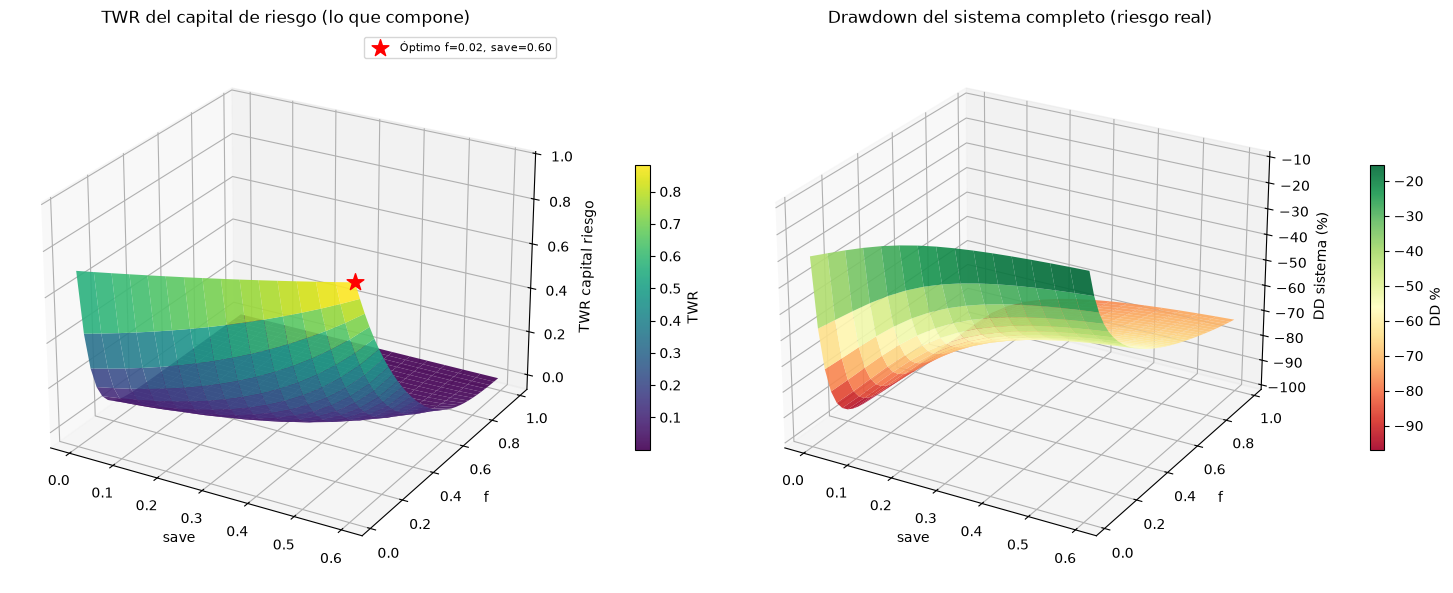

In [116]:
# Graficar las dos superficies
F, S = np.meshgrid(f_grid, save_grid, indexing='ij')
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
s1 = ax1.plot_surface(S, F, TWR, cmap='viridis', edgecolor='none', alpha=.9)
ax1.scatter(save_grid[j], f_grid[i], TWR[i,j], color='red', s=160, marker='*',
            label=f'Óptimo f={f_grid[i]:.2f}, save={save_grid[j]:.2f}')
ax1.set_xlabel('save'); ax1.set_ylabel('f'); ax1.set_zlabel('TWR capital riesgo')
ax1.set_title('TWR del capital de riesgo (lo que compone)')
ax1.view_init(elev=25, azim=-60); ax1.legend(fontsize=8)
fig.colorbar(s1, ax=ax1, shrink=.5, pad=.1, label='TWR')

ax2 = fig.add_subplot(122, projection='3d')
s2 = ax2.plot_surface(S, F, DD*100, cmap='RdYlGn', edgecolor='none', alpha=.9)
ax2.set_xlabel('save'); ax2.set_ylabel('f'); ax2.set_zlabel('DD sistema (%)')
ax2.set_title('Drawdown del sistema completo (riesgo real)')
ax2.view_init(elev=25, azim=-60)
fig.colorbar(s2, ax=ax2, shrink=.5, pad=.1, label='DD %')

plt.tight_layout(); plt.show()

In [117]:
def simular_estrategia(returns,
                       init_aum=100_000,
                       risk_per_trade=0.03,
                       avg_loss=None,
                       save_profit=0.5,
                       f=1.0):
    """
    Simula la estrategia con regla de preservación de ganancias, comparada con
    'full pnl' (reinvierte todo) y 'no risk management' (todo el capital invertido).

    Parámetros:
      returns        : serie/array de retornos por trade
      init_aum       : capital inicial
      risk_per_trade : fracción del capital a arriesgar por trade (position sizing)
      avg_loss       : pérdida promedio usada como distancia al stop.
                       Si None, se calcula de los retornos negativos.
      save_profit    : fracción de cada ganancia que se aparta (SAVE óptimo)
      f              : factor de apalancamiento sobre el sizing (F óptimo)

    Devuelve:
      DataFrame con risk_capital, profit_retained, full_pnl, no_risk_m, patrimonio_total
    """
    rnt_flat = np.asarray(returns).ravel()

    # Si no se pasa avg_loss, se estima de los retornos negativos
    if avg_loss is None:
        neg = rnt_flat[rnt_flat < 0]
        avg_loss = neg.mean() if len(neg) > 0 else -risk_per_trade

    risk_capital      = [init_aum]
    full_risk_capital = [init_aum]
    all_invested      = [init_aum]
    profit_retained   = [0.0]
    retained_cum      = 0.0

    for idx, t in enumerate(rnt_flat):
        t = float(t)
        aum          = risk_capital[idx]
        aum_full     = full_risk_capital[idx]
        aum_all_inv  = all_invested[idx]

        # Distancia al stop (nunca menos negativa que avg_loss)
        stop = np.minimum(t, avg_loss)

        # Position sizing: arriesgar risk_per_trade del capital
        risk_amount      = risk_per_trade * aum
        risk_amount_full = risk_per_trade * aum_full
        position_size      = np.abs(risk_amount / stop)
        position_size_full = np.abs(risk_amount_full / stop)

        # P&L, aplicando el factor de apalancamiento f
        pnl              = f * position_size * t
        pnl_full_capital = f * position_size_full * t
        pnl_full_inv     = aum_all_inv * t

        # Regla de preservación
        if t >= 0:
            saved   = pnl * save_profit
            to_risk = pnl - saved
        else:
            saved   = 0.0
            to_risk = pnl

        risk_capital.append(aum + to_risk)
        full_risk_capital.append(aum_full + pnl_full_capital)
        all_invested.append(aum_all_inv + pnl_full_inv)
        retained_cum += saved
        profit_retained.append(retained_cum)

    result = pd.DataFrame({
        'risk_capital':    risk_capital,
        'profit_retained': profit_retained,
        'full_pnl':        full_risk_capital,
        'no_risk_m':       all_invested,
    })
    result['patrimonio_total'] = result['risk_capital'] + result['profit_retained']
    return result

In [118]:
# ============================================================
# COMPARACIÓN FINAL: estrategia base (save=0.5) vs optimizada
# ============================================================

# Reconstruir la estrategia óptima con los parámetros encontrados en la optimización
f_opt    = f_grid[i]
save_opt = save_grid[j]

print('Pos opt: ',f_opt)
print('Save rate opt: ',save_opt)

optimal_strategy = simular_estrategia(serie_combinada['rtn'],
                                      init_aum=100_000,
                                      risk_per_trade=f_opt,
                                      save_profit=save_opt,   # el save óptimo
                                      f=1.0)


Pos opt:  0.02
Save rate opt:  0.6


# 6.7. Comparar el ejercicio

                    TWR final Retorno %  Max DD  Retorno/DD
Estrategia                                                 
Base (save=0.5)          2.97      197%  -19.1%       10.29
Óptima (save=0.60)       1.91       91%  -11.0%        8.22


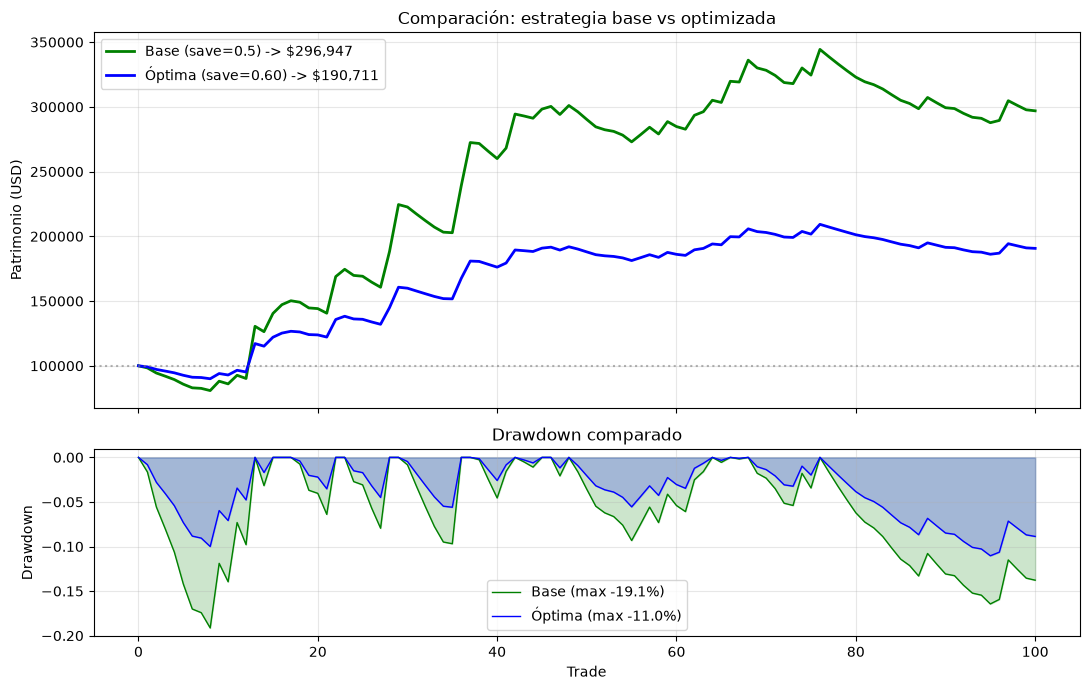

In [119]:
def drawdown(equity):
    s = pd.Series(np.asarray(equity).ravel())
    return s / s.cummax() - 1

# Métricas de cada estrategia
def resumen(df, nombre):
    eq = df['patrimonio_total']
    dd = drawdown(eq)
    twr = eq.iloc[-1] / eq.iloc[0]
    max_dd = dd.min()
    calmar = (twr - 1) / abs(max_dd) if max_dd != 0 else np.nan
    return {'Estrategia': nombre, 'TWR final': round(twr, 2),
            'Retorno %': f'{(twr-1)*100:.0f}%', 'Max DD': f'{max_dd*100:.1f}%',
            'Retorno/DD': round(calmar, 2)}

tabla = pd.DataFrame([
    resumen(result, f'Base (save=0.5)'),
    resumen(optimal_strategy, f'Óptima (save={save_opt:.2f})'),
]).set_index('Estrategia')
print(tabla)

# Gráfica comparativa con drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(result.index, result['patrimonio_total'], color='green', lw=2,
         label=f'Base (save=0.5) -> ${result["patrimonio_total"].iloc[-1]:,.0f}')
ax1.plot(optimal_strategy.index, optimal_strategy['patrimonio_total'], color='blue', lw=2,
         label=f'Óptima (save={save_opt:.2f}) -> ${optimal_strategy["patrimonio_total"].iloc[-1]:,.0f}')
ax1.axhline(100_000, color='gray', ls=':', alpha=.6)
ax1.set_ylabel('Patrimonio (USD)'); ax1.set_title('Comparación: estrategia base vs optimizada')
ax1.legend(); ax1.grid(alpha=.3)

dd_base = drawdown(result['patrimonio_total'])
dd_opt  = drawdown(optimal_strategy['patrimonio_total'])
ax2.fill_between(dd_base.index, dd_base.values, 0, color='green', alpha=.2)
ax2.plot(dd_base.index, dd_base.values, color='green', lw=1,
         label=f'Base (max {dd_base.min()*100:.1f}%)')
ax2.fill_between(dd_opt.index, dd_opt.values, 0, color='blue', alpha=.2)
ax2.plot(dd_opt.index, dd_opt.values, color='blue', lw=1,
         label=f'Óptima (max {dd_opt.min()*100:.1f}%)')
ax2.set_ylabel('Drawdown'); ax2.set_xlabel('Trade'); ax2.set_title('Drawdown comparado')
ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()